In [1]:
# ============================================================
# CELL 1: Setup and Load Data
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = r"..\..\Data\Main\modelling_dataset.csv"
OUTPUT_DIR = r"..\..\Dissertation_Results\Tables"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
model_df = model_df.sort_values(['ticker', 'date']).reset_index(drop=True)
features = ['sentiment', 'volatility_20d', 'sent_x_vol']

print(f"Data: {model_df.shape[0]:,} rows, {model_df['ticker'].nunique()} tickers")


# ============================================================
# CELL 2: Clustered Standard Errors — Full Period
# Compare: no clustering vs cluster by ticker vs cluster by date
# ============================================================

print("=" * 90)
print("CLUSTERED STANDARD ERRORS — FULL PERIOD")
print("=" * 90)

full_data = model_df.dropna(subset=features)
X = sm.add_constant(full_data[features])
y = full_data['target']

# 1. Original (no clustering)
result_nocl = sm.Logit(y, X).fit(disp=0)

# 2. Clustered by ticker
result_ticker = sm.Logit(y, X).fit(cov_type='cluster', 
                                     cov_kwds={'groups': full_data['ticker']}, 
                                     disp=0)

# 3. Clustered by date
result_date = sm.Logit(y, X).fit(cov_type='cluster', 
                                   cov_kwds={'groups': full_data['date']}, 
                                   disp=0)

print(f"\n{'Variable':<25} {'No Cluster':<20} {'Cluster: Ticker':<20} {'Cluster: Date':<20}")
print(f"{'':25} {'coef (p-val)':<20} {'coef (p-val)':<20} {'coef (p-val)':<20}")
print("-" * 85)

for var in ['const', 'sentiment', 'volatility_20d', 'sent_x_vol']:
    nc = f"{result_nocl.params[var]:.4f} ({result_nocl.pvalues[var]:.4f})"
    tc = f"{result_ticker.params[var]:.4f} ({result_ticker.pvalues[var]:.4f})"
    dc = f"{result_date.params[var]:.4f} ({result_date.pvalues[var]:.4f})"
    print(f"{var:<25} {nc:<20} {tc:<20} {dc:<20}")

print(f"\nKey question: Is sent_x_vol still significant (p < 0.05) after clustering?")
print(f"  No clustering:    p = {result_nocl.pvalues['sent_x_vol']:.4f} {'YES' if result_nocl.pvalues['sent_x_vol'] < 0.05 else 'NO'}")
print(f"  Cluster by ticker: p = {result_ticker.pvalues['sent_x_vol']:.4f} {'YES' if result_ticker.pvalues['sent_x_vol'] < 0.05 else 'NO'}")
print(f"  Cluster by date:   p = {result_date.pvalues['sent_x_vol']:.4f} {'YES' if result_date.pvalues['sent_x_vol'] < 0.05 else 'NO'}")


# ============================================================
# CELL 3: Clustered Standard Errors — Non-Overlapping Windows
# ============================================================

print("\n" + "=" * 90)
print("CLUSTERED STANDARD ERRORS — NON-OVERLAPPING 2-YEAR WINDOWS")
print("=" * 90)

windows = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

cluster_results = []

print(f"\n{'Window':<12} {'Clustering':<18} {'Interact coef':>14} {'Interact SE':>12} {'Interact p':>12} {'Sig?':>6}")
print("-" * 80)

for name, start, end in windows:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    X_w = sm.add_constant(subset[features])
    y_w = subset['target']
    
    # No clustering
    r_nc = sm.Logit(y_w, X_w).fit(disp=0)
    print(f"{name:<12} {'No cluster':<18} {r_nc.params['sent_x_vol']:>14.4f} {r_nc.bse['sent_x_vol']:>12.4f} {r_nc.pvalues['sent_x_vol']:>12.4f} {'***' if r_nc.pvalues['sent_x_vol'] < 0.01 else '**' if r_nc.pvalues['sent_x_vol'] < 0.05 else 'ns':>6}")
    
    # Cluster by ticker
    r_tc = sm.Logit(y_w, X_w).fit(cov_type='cluster', cov_kwds={'groups': subset['ticker']}, disp=0)
    print(f"{'':12} {'Cluster: ticker':<18} {r_tc.params['sent_x_vol']:>14.4f} {r_tc.bse['sent_x_vol']:>12.4f} {r_tc.pvalues['sent_x_vol']:>12.4f} {'***' if r_tc.pvalues['sent_x_vol'] < 0.01 else '**' if r_tc.pvalues['sent_x_vol'] < 0.05 else 'ns':>6}")
    
    # Cluster by date
    r_dc = sm.Logit(y_w, X_w).fit(cov_type='cluster', cov_kwds={'groups': subset['date']}, disp=0)
    print(f"{'':12} {'Cluster: date':<18} {r_dc.params['sent_x_vol']:>14.4f} {r_dc.bse['sent_x_vol']:>12.4f} {r_dc.pvalues['sent_x_vol']:>12.4f} {'***' if r_dc.pvalues['sent_x_vol'] < 0.01 else '**' if r_dc.pvalues['sent_x_vol'] < 0.05 else 'ns':>6}")
    print()
    
    for cl_type, r in [('No cluster', r_nc), ('Cluster: ticker', r_tc), ('Cluster: date', r_dc)]:
        cluster_results.append({
            'Window': name, 'Clustering': cl_type,
            'Interact coef': round(r.params['sent_x_vol'], 4),
            'Interact SE': round(r.bse['sent_x_vol'], 4),
            'Interact p': round(r.pvalues['sent_x_vol'], 4),
            'Significant': 'Yes' if r.pvalues['sent_x_vol'] < 0.05 else 'No'
        })

cluster_df = pd.DataFrame(cluster_results)
cluster_df.to_csv(os.path.join(OUTPUT_DIR, "Table_Clustered_SE_Results.csv"), index=False)
print("Saved: Table_Clustered_SE_Results.csv")


# ============================================================
# CELL 4: Marginal Effects — Full Period
# Shows how the effect of sentiment changes at different volatility levels
# ============================================================

print("\n" + "=" * 90)
print("MARGINAL EFFECTS — EFFECT OF SENTIMENT AT DIFFERENT VOLATILITY LEVELS")
print("=" * 90)

# Use the full period model (no clustering — coefficients are the same regardless)
full_data = model_df.dropna(subset=features).copy()
X = sm.add_constant(full_data[features])
y = full_data['target']
result = sm.Logit(y, X).fit(disp=0)

# Get volatility percentiles
vol_levels = {
    '10th percentile (very calm)': full_data['volatility_20d'].quantile(0.10),
    '25th percentile (calm)': full_data['volatility_20d'].quantile(0.25),
    '50th percentile (median)': full_data['volatility_20d'].quantile(0.50),
    '75th percentile (volatile)': full_data['volatility_20d'].quantile(0.75),
    '90th percentile (very volatile)': full_data['volatility_20d'].quantile(0.90),
}

print(f"\nModel coefficients:")
print(f"  β_sentiment = {result.params['sentiment']:.4f}")
print(f"  β_volatility = {result.params['volatility_20d']:.4f}")
print(f"  β_interaction = {result.params['sent_x_vol']:.4f}")
print(f"  constant = {result.params['const']:.4f}")

print(f"\nThe marginal effect of sentiment on the log-odds of a positive return is:")
print(f"  dLogit/dSentiment = β_sentiment + β_interaction × volatility_20d")
print(f"  = {result.params['sentiment']:.4f} + {result.params['sent_x_vol']:.4f} × volatility_20d\n")

print(f"{'Volatility Level':<35} {'Vol Value':>10} {'Marginal Effect':>16} {'Direction':>12}")
print("-" * 78)

marginal_results = []

for name, vol_val in vol_levels.items():
    # Marginal effect of sentiment on log-odds
    marginal_logodds = result.params['sentiment'] + result.params['sent_x_vol'] * vol_val
    
    # Convert to probability change (at the mean)
    # Average predicted probability
    mean_pred = result.predict(X).mean()
    # Marginal effect on probability = marginal_logodds * p * (1-p)
    marginal_prob = marginal_logodds * mean_pred * (1 - mean_pred)
    
    direction = 'Positive' if marginal_logodds > 0 else 'Negative'
    
    print(f"{name:<35} {vol_val:>10.4f} {marginal_logodds:>+16.4f} {direction:>12}")
    
    marginal_results.append({
        'Volatility Level': name,
        'Volatility Value': round(vol_val, 4),
        'Marginal Effect (log-odds)': round(marginal_logodds, 4),
        'Marginal Effect (probability)': round(marginal_prob, 6),
        'Direction': direction,
    })

print(f"\nInterpretation:")
print(f"  At low volatility, the effect of sentiment on return direction is negative")
print(f"  (more positive sentiment → slightly lower probability of positive return).")
print(f"  At high volatility, the effect becomes positive or less negative")
print(f"  (more positive sentiment → slightly higher probability of positive return).")
print(f"  This is the moderation effect in action.")

# Also compute the crossover point where effect = 0
crossover = -result.params['sentiment'] / result.params['sent_x_vol']
pct_below = (full_data['volatility_20d'] < crossover).mean() * 100
print(f"\nCrossover point (where sentiment effect = 0): volatility = {crossover:.4f}")
print(f"  {pct_below:.1f}% of observations are below this threshold")
print(f"  Above this volatility, sentiment has a positive marginal effect on return direction")


# ============================================================
# CELL 5: Marginal Effects — Per Window
# Shows how the marginal effect differs AND sign-flips across windows
# ============================================================

print("\n" + "=" * 90)
print("MARGINAL EFFECTS — PER NON-OVERLAPPING WINDOW")
print("=" * 90)

print(f"\n{'Window':<12} {'Vol Level':<25} {'Vol Value':>10} {'Marginal Effect':>16} {'Direction':>12}")
print("-" * 80)

window_marginal_results = []

for wname, start, end in windows:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    X_w = sm.add_constant(subset[features])
    y_w = subset['target']
    r = sm.Logit(y_w, X_w).fit(disp=0)
    
    for vname, vpct in [('25th pct', 0.25), ('50th pct', 0.50), ('75th pct', 0.75)]:
        vol_val = subset['volatility_20d'].quantile(vpct)
        marginal = r.params['sentiment'] + r.params['sent_x_vol'] * vol_val
        direction = 'Positive' if marginal > 0 else 'Negative'
        
        print(f"{wname:<12} {vname:<25} {vol_val:>10.4f} {marginal:>+16.4f} {direction:>12}")
        
        window_marginal_results.append({
            'Window': wname, 'Volatility Level': vname,
            'Volatility Value': round(vol_val, 4),
            'Marginal Effect': round(marginal, 4),
            'Direction': direction,
        })
    print()

# Save all results
marginal_df = pd.DataFrame(marginal_results)
marginal_df.to_csv(os.path.join(OUTPUT_DIR, "Table_Marginal_Effects_Full.csv"), index=False)

window_marginal_df = pd.DataFrame(window_marginal_results)
window_marginal_df.to_csv(os.path.join(OUTPUT_DIR, "Table_Marginal_Effects_Windows.csv"), index=False)

print("Saved: Table_Marginal_Effects_Full.csv")
print("Saved: Table_Marginal_Effects_Windows.csv")


# ============================================================
# CELL 6: Summary
# ============================================================

print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

print("""
WHAT TO CHECK:

1. CLUSTERED STANDARD ERRORS:
   - If interaction term is STILL significant after clustering → your finding is genuinely robust
   - If it becomes non-significant → soften claims, mention as limitation
   - Coefficients don't change — only standard errors and p-values change

2. MARGINAL EFFECTS:
   - Shows the PRACTICAL SIZE of the moderation effect
   - At low volatility: sentiment effect is X
   - At high volatility: sentiment effect is Y
   - The difference between X and Y is the moderation effect in practical terms

3. FOR THE PAPER:
   - Add one sentence in methodology: "Standard errors were clustered by [ticker/date] 
     to account for within-group correlation"
   - Add marginal effects table in results (Section 4.2) after the interaction term tables
   - If clustering weakens some p-values, acknowledge honestly

FILES SAVED:
   - Table_Clustered_SE_Results.csv
   - Table_Marginal_Effects_Full.csv
   - Table_Marginal_Effects_Windows.csv
""")

Data: 578,903 rows, 523 tickers
CLUSTERED STANDARD ERRORS — FULL PERIOD

Variable                  No Cluster           Cluster: Ticker      Cluster: Date       
                          coef (p-val)         coef (p-val)         coef (p-val)        
-------------------------------------------------------------------------------------
const                     0.0686 (0.0000)      0.0686 (0.0000)      0.0686 (0.0812)     
sentiment                 -0.0571 (0.0004)     -0.0571 (0.0002)     -0.0571 (0.3197)    
volatility_20d            0.1003 (0.6170)      0.1003 (0.6019)      0.1003 (0.9488)     
sent_x_vol                1.3595 (0.0321)      1.3595 (0.0304)      1.3595 (0.3261)     

Key question: Is sent_x_vol still significant (p < 0.05) after clustering?
  No clustering:    p = 0.0321 YES
  Cluster by ticker: p = 0.0304 YES
  Cluster by date:   p = 0.3261 NO

CLUSTERED STANDARD ERRORS — NON-OVERLAPPING 2-YEAR WINDOWS

Window       Clustering          Interact coef  Interact SE   In

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
features = ['sentiment', 'volatility_20d', 'sent_x_vol']

overlap = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2021-2022', '2021-01-01', '2022-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2023-2024', '2023-01-01', '2024-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

print(f"{'Window':<12} {'Interact coef':>14} {'Interact p (ticker)':>20} {'Sig?':>6}")
print("-" * 55)

for name, start, end in overlap:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    X = sm.add_constant(subset[features])
    y = subset['target']
    r = sm.Logit(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['ticker']}, disp=0)
    sig = "***" if r.pvalues['sent_x_vol'] < 0.01 else "**" if r.pvalues['sent_x_vol'] < 0.05 else "ns"
    print(f"{name:<12} {r.params['sent_x_vol']:>14.4f} {r.pvalues['sent_x_vol']:>20.4f} {sig:>6}")

Window        Interact coef  Interact p (ticker)   Sig?
-------------------------------------------------------
2020-2021            2.4098               0.0052    ***
2021-2022           -2.8847               0.0107     **
2022-2023           -3.7714               0.0003    ***
2023-2024            3.1157               0.0336     **
2024-2025            6.5711               0.0000    ***


In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
features = ['sentiment', 'volatility_20d', 'sent_x_vol']
OUTPUT_DIR = r"..\..\Dissertation_Results\Tables"

overlap = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2021-2022', '2021-01-01', '2022-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2023-2024', '2023-01-01', '2024-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

rows = []
for name, start, end in overlap:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    X = sm.add_constant(subset[features])
    y = subset['target']
    r = sm.Logit(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['ticker']}, disp=0)
    rows.append({
        'Window': name,
        'N': len(subset),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Significant': 'Yes' if r.pvalues['sent_x_vol'] < 0.05 else 'No',
        'Direction': 'Positive' if r.params['sent_x_vol'] > 0 else 'Negative',
    })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))
result_df.to_csv(os.path.join(OUTPUT_DIR, "Table3_Overlap_Results_Clustered.csv"), index=False)
print("\nSaved: Table3_Overlap_Results_Clustered.csv")

   Window      N  Interact coef  Interact p Significant Direction
2020-2021 165150         2.4098      0.0052         Yes  Positive
2021-2022 195969        -2.8847      0.0107         Yes  Negative
2022-2023 210029        -3.7714      0.0003         Yes  Negative
2023-2024 209647         3.1157      0.0336         Yes  Positive
2024-2025 203724         6.5711      0.0000         Yes  Positive

Saved: Table3_Overlap_Results_Clustered.csv


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
features = ['sentiment', 'volatility_20d', 'sent_x_vol']
OUTPUT_DIR = r"..\..\Dissertation_Results\Tables"

# === 1. Full Period (ticker-clustered) ===
full_data = model_df.dropna(subset=features)
X = sm.add_constant(full_data[features])
y = full_data['target']
r = sm.Logit(y, X).fit(cov_type='cluster', cov_kwds={'groups': full_data['ticker']}, disp=0)

full_table = pd.DataFrame({
    'Variable': ['Constant', 'Sentiment', 'Volatility_20d', 'Sentiment × Volatility'],
    'Coefficient': r.params.round(4).values,
    'Std Error': r.bse.round(4).values,
    'z-statistic': r.tvalues.round(3).values,
    'p-value': r.pvalues.round(4).values,
})
print("=== FULL PERIOD (ticker-clustered) ===")
print(full_table.to_string(index=False))
full_table.to_csv(os.path.join(OUTPUT_DIR, "Table_Full_Period_Regression.csv"), index=False)
print("Saved: Table_Full_Period_Regression.csv\n")

# === 2. Non-Overlapping Windows (ticker-clustered) ===
non_overlap = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

rows = []
for name, start, end in non_overlap:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    X_w = sm.add_constant(subset[features])
    y_w = subset['target']
    r_w = sm.Logit(y_w, X_w).fit(cov_type='cluster', cov_kwds={'groups': subset['ticker']}, disp=0)
    rows.append({
        'Window': name, 'N': len(subset),
        'Sent coef': round(r_w.params['sentiment'], 4),
        'Sent p': round(r_w.pvalues['sentiment'], 4),
        'Vol coef': round(r_w.params['volatility_20d'], 4),
        'Vol p': round(r_w.pvalues['volatility_20d'], 4),
        'Interact coef': round(r_w.params['sent_x_vol'], 4),
        'Interact p': round(r_w.pvalues['sent_x_vol'], 4),
    })

non_overlap_df = pd.DataFrame(rows)
print("=== NON-OVERLAPPING WINDOWS (ticker-clustered) ===")
print(non_overlap_df.to_string(index=False))
non_overlap_df.to_csv(os.path.join(OUTPUT_DIR, "Table2_NonOverlap_Results.csv"), index=False)
print("Saved: Table2_NonOverlap_Results.csv\n")

# === 3. Overlapping Windows (ticker-clustered) ===
overlap = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2021-2022', '2021-01-01', '2022-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2023-2024', '2023-01-01', '2024-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

rows2 = []
for name, start, end in overlap:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    X_w = sm.add_constant(subset[features])
    y_w = subset['target']
    r_w = sm.Logit(y_w, X_w).fit(cov_type='cluster', cov_kwds={'groups': subset['ticker']}, disp=0)
    rows2.append({
        'Window': name, 'N': len(subset),
        'Interact coef': round(r_w.params['sent_x_vol'], 4),
        'Interact p': round(r_w.pvalues['sent_x_vol'], 4),
        'Significant': 'Yes' if r_w.pvalues['sent_x_vol'] < 0.05 else 'No',
        'Direction': 'Positive' if r_w.params['sent_x_vol'] > 0 else 'Negative',
    })

overlap_df = pd.DataFrame(rows2)
print("=== OVERLAPPING WINDOWS (ticker-clustered) ===")
print(overlap_df.to_string(index=False))
overlap_df.to_csv(os.path.join(OUTPUT_DIR, "Table3_Overlap_Results.csv"), index=False)
print("Saved: Table3_Overlap_Results.csv\n")

print("ALL THREE TABLES OVERWRITTEN WITH TICKER-CLUSTERED VALUES")

=== FULL PERIOD (ticker-clustered) ===
              Variable  Coefficient  Std Error  z-statistic  p-value
              Constant       0.0686     0.0051       13.413   0.0000
             Sentiment      -0.0571     0.0156       -3.671   0.0002
        Volatility_20d       0.1003     0.1923        0.522   0.6019
Sentiment × Volatility       1.3595     0.6279        2.165   0.0304
Saved: Table_Full_Period_Regression.csv

=== NON-OVERLAPPING WINDOWS (ticker-clustered) ===
   Window      N  Sent coef  Sent p  Vol coef  Vol p  Interact coef  Interact p
2020-2021 165150    -0.0347  0.1964   -0.6322 0.0042         2.4098      0.0052
2022-2023 210029     0.0175  0.4714    0.1761 0.6954        -3.7714      0.0003
2024-2025 203724    -0.1660  0.0000    0.7172 0.1467         6.5711      0.0000
Saved: Table2_NonOverlap_Results.csv

=== OVERLAPPING WINDOWS (ticker-clustered) ===
   Window      N  Interact coef  Interact p Significant Direction
2020-2021 165150         2.4098      0.0052         Y

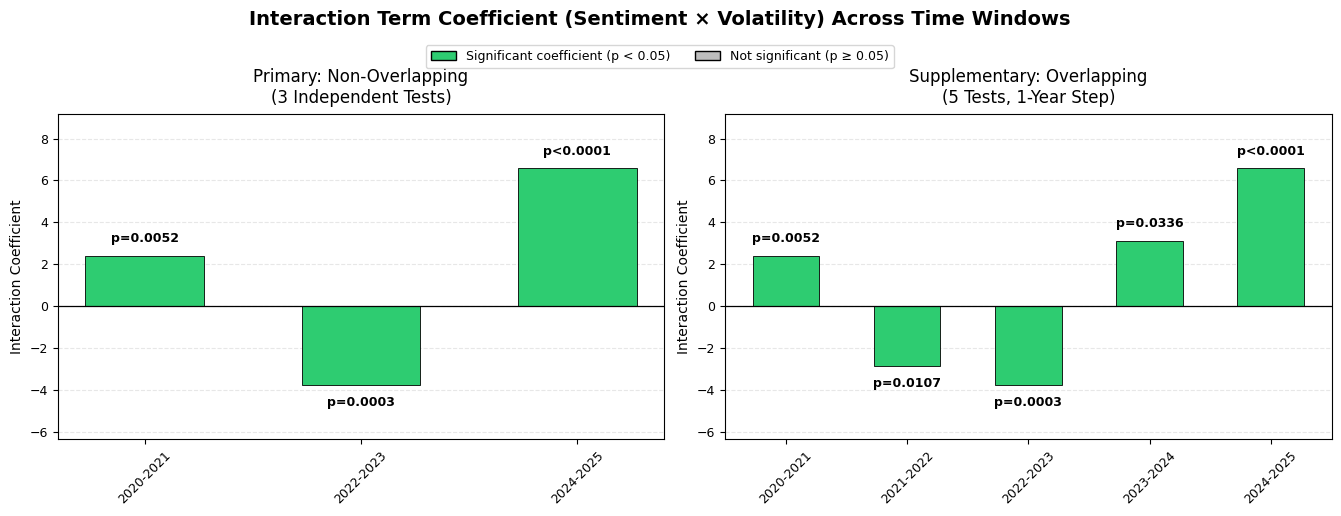

Saved: Fig_Interaction_Coefficients.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

OUTPUT_DIR = r"..\..\Dissertation_Results\Figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

non_overlap = pd.read_csv(r"..\..\Dissertation_Results\Tables\Table2_NonOverlap_Results.csv")
overlap = pd.read_csv(r"..\..\Dissertation_Results\Tables\Table3_Overlap_Results.csv")

# Significance threshold
ALPHA = 0.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

fig.suptitle(
    "Interaction Term Coefficient (Sentiment × Volatility) Across Time Windows",
    fontsize=14,
    fontweight="bold",
    y=0.96
)

for ax, df, title in [
    (axes[0], non_overlap, "Primary: Non-Overlapping\n(3 Independent Tests)"),
    (axes[1], overlap, "Supplementary: Overlapping\n(5 Tests, 1-Year Step)")
]:
    coefs = df["Interact coef"].values
    pvals = df["Interact p"].values
    windows = df["Window"].values

    # Green if significant, grey if not significant
    colors = ["#2ecc71" if p < ALPHA else "#bdbdbd" for p in pvals]

    bars = ax.bar(
        windows,
        coefs,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
        width=0.55
    )

    ax.axhline(y=0, color="black", linewidth=0.9)

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_ylabel("Interaction Coefficient", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

    # Add light grid for readability
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    # Dynamic y-axis margins
    y_min = min(coefs)
    y_max = max(coefs)
    y_range = y_max - y_min

    if y_range == 0:
        y_range = abs(y_max) if y_max != 0 else 1

    ax.set_ylim(
        y_min - (0.25 * y_range),
        y_max + (0.25 * y_range)
    )

    # p-value labels
    for i, (bar, coef, p) in enumerate(zip(bars, coefs, pvals)):
        p_label = f"p={p:.4f}" if p >= 0.0001 else "p<0.0001"

        if coef >= 0:
            y_pos = coef + (0.05 * y_range)
            va = "bottom"
        else:
            y_pos = coef - (0.05 * y_range)
            va = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            p_label,
            ha="center",
            va=va,
            fontsize=9,
            fontweight="bold"
        )

# Updated legend
legend_items = [
    mpatches.Patch(facecolor="#2ecc71", edgecolor="black", label="Significant coefficient (p < 0.05)"),
    mpatches.Patch(facecolor="#bdbdbd", edgecolor="black", label="Not significant (p ≥ 0.05)")
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    ncol=2,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 0.91)
)

# Better spacing
plt.subplots_adjust(
    top=0.78,
    bottom=0.22,
    left=0.07,
    right=0.98,
    wspace=0.10
)

save_path = os.path.join(OUTPUT_DIR, "Fig_Interaction_Coefficients.png")

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Fig_Interaction_Coefficients.png")

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
features = ['sentiment', 'volatility_20d', 'sent_x_vol']
OUTPUT_DIR = r"..\..\Dissertation_Results\Tables"

# === Table 5a: Threshold Sensitivity (ticker-clustered) ===
print("=== THRESHOLD SENSITIVITY (ticker-clustered) ===")
quantiles = [0.25, 0.50, 0.75]
rows_5a = []
for q in quantiles:
    cutoff = model_df['market_vol'].quantile(q)
    vol_data = model_df[model_df['market_vol'] > cutoff].dropna(subset=features)
    calm_data = model_df[model_df['market_vol'] <= cutoff].dropna(subset=features)
    
    r_vol = sm.Logit(vol_data['target'], sm.add_constant(vol_data[features])).fit(
        cov_type='cluster', cov_kwds={'groups': vol_data['ticker']}, disp=0)
    r_calm = sm.Logit(calm_data['target'], sm.add_constant(calm_data[features])).fit(
        cov_type='cluster', cov_kwds={'groups': calm_data['ticker']}, disp=0)
    
    rows_5a.append({
        'Threshold': f"{int(q*100)}th percentile",
        'Cutoff': round(cutoff, 4),
        'Volatile N': len(vol_data),
        'Volatile Interact p': round(r_vol.pvalues['sent_x_vol'], 4),
        'Volatile sig': 'Yes' if r_vol.pvalues['sent_x_vol'] < 0.05 else 'No',
        'Calm N': len(calm_data),
        'Calm Interact p': round(r_calm.pvalues['sent_x_vol'], 4),
        'Calm sig': 'Yes' if r_calm.pvalues['sent_x_vol'] < 0.05 else 'No',
    })

table5a = pd.DataFrame(rows_5a)
print(table5a.to_string(index=False))
table5a.to_csv(os.path.join(OUTPUT_DIR, "Table5a_Threshold_Sensitivity.csv"), index=False)
print("Saved: Table5a_Threshold_Sensitivity.csv\n")

# === Table 5b: Zero-Sentiment Exclusion (ticker-clustered) ===
print("=== ZERO-SENTIMENT EXCLUSION (ticker-clustered) ===")
full_data = model_df.dropna(subset=features)
nonzero_data = model_df[model_df['sentiment'] != 0].dropna(subset=features)

non_overlap = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

rows_5b = []
for name, start, end in non_overlap:
    with_z = full_data[(full_data['date'] >= start) & (full_data['date'] <= end)]
    without_z = nonzero_data[(nonzero_data['date'] >= start) & (nonzero_data['date'] <= end)]
    
    r_wz = sm.Logit(with_z['target'], sm.add_constant(with_z[features])).fit(
        cov_type='cluster', cov_kwds={'groups': with_z['ticker']}, disp=0)
    r_woz = sm.Logit(without_z['target'], sm.add_constant(without_z[features])).fit(
        cov_type='cluster', cov_kwds={'groups': without_z['ticker']}, disp=0)
    
    rows_5b.append({
        'Window': name,
        'With zeros N': len(with_z),
        'With zeros Interact p': round(r_wz.pvalues['sent_x_vol'], 4),
        'With zeros sig': 'Yes' if r_wz.pvalues['sent_x_vol'] < 0.05 else 'No',
        'Without zeros N': len(without_z),
        'Without zeros Interact p': round(r_woz.pvalues['sent_x_vol'], 4),
        'Without zeros sig': 'Yes' if r_woz.pvalues['sent_x_vol'] < 0.05 else 'No',
    })

table5b = pd.DataFrame(rows_5b)
print(table5b.to_string(index=False))
table5b.to_csv(os.path.join(OUTPUT_DIR, "Table5b_Zero_Sentiment.csv"), index=False)
print("Saved: Table5b_Zero_Sentiment.csv\n")

# === Table 5c: Per-Stock vs Market-Wide Volatility (ticker-clustered) ===
print("=== PER-STOCK VS MARKET-WIDE VOLATILITY (ticker-clustered) ===")
model_df_copy = model_df.copy()
model_df_copy['stock_vol_median'] = model_df_copy.groupby('ticker')['volatility_20d'].transform('median')
model_df_copy['stock_volatile'] = (model_df_copy['volatility_20d'] > model_df_copy['stock_vol_median']).astype(int)

tests = [
    ('Stock-level volatile', model_df_copy[model_df_copy['stock_volatile'] == 1].dropna(subset=features)),
    ('Stock-level calm', model_df_copy[model_df_copy['stock_volatile'] == 0].dropna(subset=features)),
    ('Market-wide volatile', model_df[model_df['volatile_market'] == 1].dropna(subset=features)),
    ('Market-wide calm', model_df[model_df['volatile_market'] == 0].dropna(subset=features)),
]

rows_5c = []
for name, data in tests:
    r = sm.Logit(data['target'], sm.add_constant(data[features])).fit(
        cov_type='cluster', cov_kwds={'groups': data['ticker']}, disp=0)
    rows_5c.append({
        'Regime': name,
        'N': len(data),
        'Interact coef': round(r.params['sent_x_vol'], 4),
        'Interact p': round(r.pvalues['sent_x_vol'], 4),
        'Significant': 'Yes' if r.pvalues['sent_x_vol'] < 0.05 else 'No',
    })

table5c = pd.DataFrame(rows_5c)
print(table5c.to_string(index=False))
table5c.to_csv(os.path.join(OUTPUT_DIR, "Table5c_Volatility_Definition.csv"), index=False)
print("Saved: Table5c_Volatility_Definition.csv\n")

print("ALL THREE ROBUSTNESS TABLES OVERWRITTEN WITH TICKER-CLUSTERED VALUES")

=== THRESHOLD SENSITIVITY (ticker-clustered) ===
      Threshold  Cutoff  Volatile N  Volatile Interact p Volatile sig  Calm N  Calm Interact p Calm sig
25th percentile  0.0171      433904               0.0071          Yes  144999           0.8754       No
50th percentile  0.0192      289192               0.0051          Yes  289711           0.3044       No
75th percentile  0.0225      144503               0.0002          Yes  434400           0.5534       No
Saved: Table5a_Threshold_Sensitivity.csv

=== ZERO-SENTIMENT EXCLUSION (ticker-clustered) ===
   Window  With zeros N  With zeros Interact p With zeros sig  Without zeros N  Without zeros Interact p Without zeros sig
2020-2021        165150                 0.0052            Yes            93292                    0.0065               Yes
2022-2023        210029                 0.0003            Yes           185242                    0.0001               Yes
2024-2025        203724                 0.0000            Yes           

=== OVERLAPPING WINDOWS: ALL VARIABLES (ticker-clustered) ===
   Window  Sent p Sent sig  Vol p Vol sig  Interact p Interact sig
2020-2021  0.1964       No 0.0042     Yes      0.0052          Yes
2021-2022  0.7287       No 0.0008     Yes      0.0107          Yes
2022-2023  0.4714       No 0.6954      No      0.0003          Yes
2023-2024  0.1872       No 0.2229      No      0.0336          Yes
2024-2025  0.0000      Yes 0.1467      No      0.0000          Yes

Sentiment significant: 1/5 windows
Volatility significant: 2/5 windows
Interaction significant: 5/5 windows

Saved: Table_Overlap_All_Variables_Clustered.csv


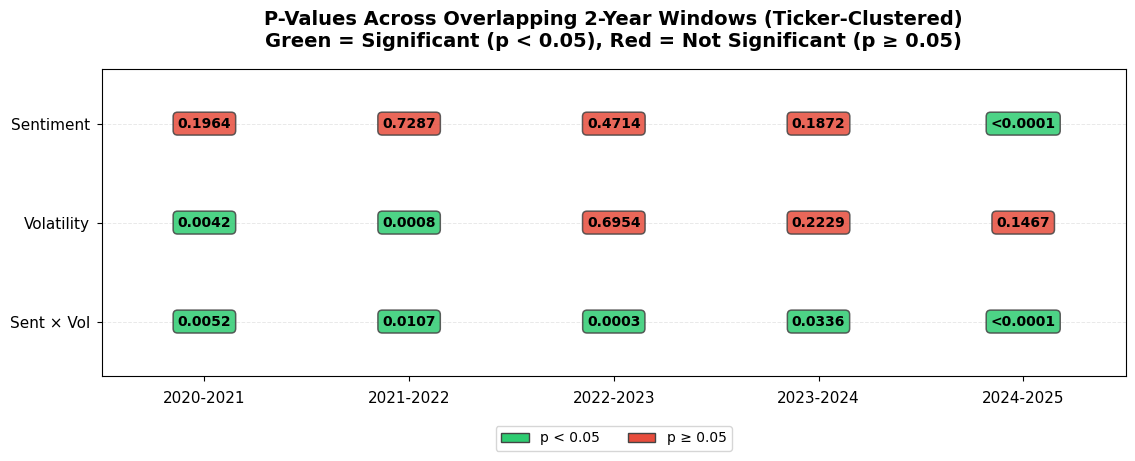

Saved: Fig_PValue_Comparison_Clustered.png


In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

model_df = df.dropna(subset=["volatility_20d", "next_day_return"]).copy()

features = ["sentiment", "volatility_20d", "sent_x_vol"]

OUTPUT_DIR = r"..\..\Dissertation_Results"
os.makedirs(os.path.join(OUTPUT_DIR, "Tables"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "Figures"), exist_ok=True)

overlap = [
    ("2020-2021", "2020-01-01", "2021-12-31"),
    ("2021-2022", "2021-01-01", "2022-12-31"),
    ("2022-2023", "2022-01-01", "2023-12-31"),
    ("2023-2024", "2023-01-01", "2024-12-31"),
    ("2024-2025", "2024-01-01", "2025-12-31"),
]

# -----------------------------
# Run logistic regressions
# -----------------------------
rows = []

for name, start, end in overlap:
    subset = model_df[
        (model_df["date"] >= start) &
        (model_df["date"] <= end)
    ].dropna(subset=features)

    X = sm.add_constant(subset[features])
    y = subset["target"]

    r = sm.Logit(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": subset["ticker"]},
        disp=0
    )

    rows.append({
        "Window": name,
        "Sent p": r.pvalues["sentiment"],
        "Sent sig": "Yes" if r.pvalues["sentiment"] < 0.05 else "No",
        "Vol p": r.pvalues["volatility_20d"],
        "Vol sig": "Yes" if r.pvalues["volatility_20d"] < 0.05 else "No",
        "Interact p": r.pvalues["sent_x_vol"],
        "Interact sig": "Yes" if r.pvalues["sent_x_vol"] < 0.05 else "No",
    })

result_df = pd.DataFrame(rows)

print("=== OVERLAPPING WINDOWS: ALL VARIABLES (ticker-clustered) ===")
print(result_df.round(4).to_string(index=False))

# -----------------------------
# Count significant windows
# -----------------------------
sent_sig = sum(1 for r in rows if r["Sent sig"] == "Yes")
vol_sig = sum(1 for r in rows if r["Vol sig"] == "Yes")
int_sig = sum(1 for r in rows if r["Interact sig"] == "Yes")

print(f"\nSentiment significant: {sent_sig}/5 windows")
print(f"Volatility significant: {vol_sig}/5 windows")
print(f"Interaction significant: {int_sig}/5 windows")

# Save table
result_df.round(4).to_csv(
    os.path.join(OUTPUT_DIR, "Tables", "Table_Overlap_All_Variables_Clustered.csv"),
    index=False
)

print("\nSaved: Table_Overlap_All_Variables_Clustered.csv")

# -----------------------------
# Create p-value comparison figure
# -----------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.2))

var_labels = ["Sentiment", "Volatility", "Sent × Vol"]
var_keys = ["Sent p", "Vol p", "Interact p"]
window_names = [r["Window"] for r in rows]

y_positions = [2, 1, 0]

for y_pos, var_key in zip(y_positions, var_keys):
    for i, r in enumerate(rows):
        p = r[var_key]

        # Green = significant, Red = not significant
        box_color = "#2ecc71" if p < 0.05 else "#e74c3c"

        p_label = f"{p:.4f}" if p >= 0.0001 else "<0.0001"

        ax.text(
            i,
            y_pos,
            p_label,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.32",
                facecolor=box_color,
                edgecolor="#444444",
                linewidth=1.1,
                alpha=0.85
            )
        )

# -----------------------------
# Axis formatting
# -----------------------------
ax.set_yticks(y_positions)
ax.set_yticklabels(var_labels, fontsize=11)

ax.set_xticks(range(len(window_names)))
ax.set_xticklabels(window_names, fontsize=11)

ax.set_xlim(-0.5, len(window_names) - 0.5)
ax.set_ylim(-0.55, 2.55)

ax.set_title(
    "P-Values Across Overlapping 2-Year Windows (Ticker-Clustered)\n"
    "Green = Significant (p < 0.05), Red = Not Significant (p ≥ 0.05)",
    fontsize=14,
    fontweight="bold",
    pad=16
)

# Light horizontal guide lines
for y in y_positions:
    ax.axhline(
        y=y,
        color="lightgrey",
        linestyle="--",
        linewidth=0.7,
        alpha=0.5,
        zorder=0
    )

ax.tick_params(axis="x", pad=7)
ax.tick_params(axis="y", pad=5)

# -----------------------------
# Legend
# -----------------------------
legend_items = [
    mpatches.Patch(facecolor="#2ecc71", edgecolor="#444444", label="p < 0.05"),
    mpatches.Patch(facecolor="#e74c3c", edgecolor="#444444", label="p ≥ 0.05")
]

ax.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    fontsize=10,
    frameon=True
)

# -----------------------------
# Margins and save
# -----------------------------
plt.subplots_adjust(
    top=0.82,
    bottom=0.23,
    left=0.09,
    right=0.98
)

save_path = os.path.join(
    OUTPUT_DIR,
    "Figures",
    "Fig_PValue_Comparison_Clustered.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Fig_PValue_Comparison_Clustered.png")

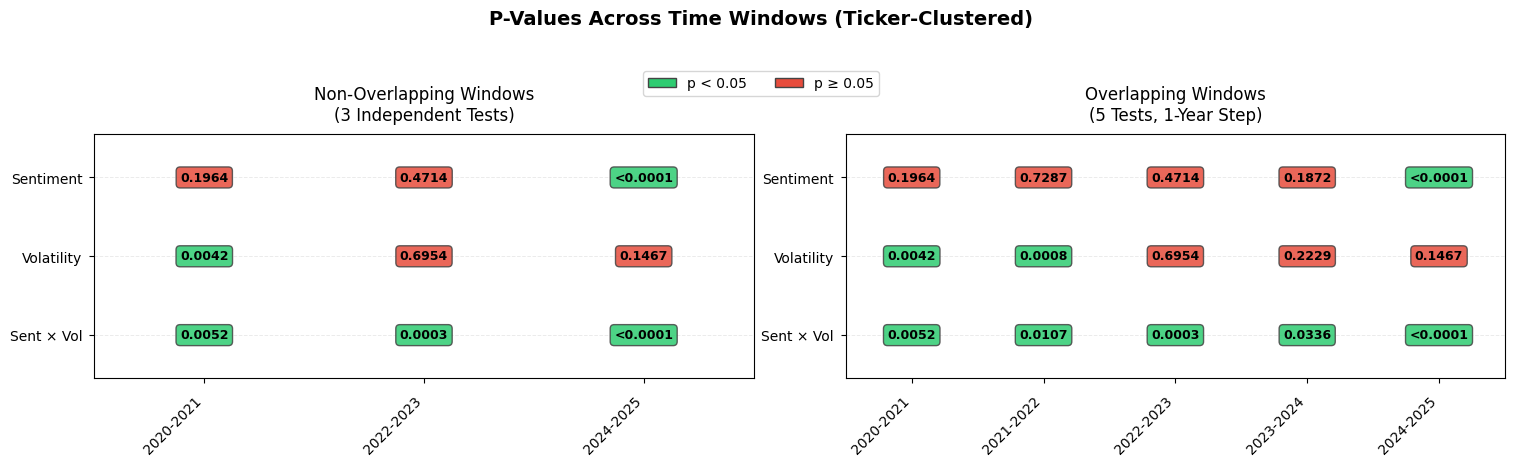

Saved: Fig_PValue_Comparison_Both.png


In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

model_df = df.dropna(subset=["volatility_20d", "next_day_return"]).copy()

features = ["sentiment", "volatility_20d", "sent_x_vol"]

OUTPUT_DIR = r"..\..\Dissertation_Results"
os.makedirs(os.path.join(OUTPUT_DIR, "Figures"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "Tables"), exist_ok=True)

# -----------------------------
# Define windows
# -----------------------------
non_overlap = [
    ("2020-2021", "2020-01-01", "2021-12-31"),
    ("2022-2023", "2022-01-01", "2023-12-31"),
    ("2024-2025", "2024-01-01", "2025-12-31"),
]

overlap = [
    ("2020-2021", "2020-01-01", "2021-12-31"),
    ("2021-2022", "2021-01-01", "2022-12-31"),
    ("2022-2023", "2022-01-01", "2023-12-31"),
    ("2023-2024", "2023-01-01", "2024-12-31"),
    ("2024-2025", "2024-01-01", "2025-12-31"),
]

# -----------------------------
# Function to calculate p-values
# -----------------------------
def get_pvalues(windows):
    rows = []

    for name, start, end in windows:
        subset = model_df[
            (model_df["date"] >= start) &
            (model_df["date"] <= end)
        ].dropna(subset=features)

        X = sm.add_constant(subset[features])
        y = subset["target"]

        r = sm.Logit(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": subset["ticker"]},
            disp=0
        )

        rows.append({
            "Window": name,
            "Sent p": r.pvalues["sentiment"],
            "Vol p": r.pvalues["volatility_20d"],
            "Interact p": r.pvalues["sent_x_vol"],
        })

    return rows

no_rows = get_pvalues(non_overlap)
ol_rows = get_pvalues(overlap)

# Save tables
pd.DataFrame(no_rows).round(4).to_csv(
    os.path.join(OUTPUT_DIR, "Tables", "Table_NonOverlap_All_PValues.csv"),
    index=False
)

pd.DataFrame(ol_rows).round(4).to_csv(
    os.path.join(OUTPUT_DIR, "Tables", "Table_Overlap_All_PValues.csv"),
    index=False
)

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))

fig.suptitle(
    "P-Values Across Time Windows (Ticker-Clustered)\n",
    fontsize=14,
    fontweight="bold",
    y=0.96
)

var_labels = ["Sentiment", "Volatility", "Sent × Vol"]
var_keys = ["Sent p", "Vol p", "Interact p"]
y_positions = [2, 1, 0]

for ax, rows, title in [
    (axes[0], no_rows, "Non-Overlapping Windows\n(3 Independent Tests)"),
    (axes[1], ol_rows, "Overlapping Windows\n(5 Tests, 1-Year Step)")
]:
    window_names = [r["Window"] for r in rows]

    for y_pos, var_key in zip(y_positions, var_keys):
        for i, r in enumerate(rows):
            p = r[var_key]

            box_color = "#2ecc71" if p < 0.05 else "#e74c3c"
            p_label = f"{p:.4f}" if p >= 0.0001 else "<0.0001"

            ax.text(
                i,
                y_pos,
                p_label,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.32",
                    facecolor=box_color,
                    edgecolor="#444444",
                    linewidth=1.0,
                    alpha=0.85
                )
            )

    # Axis formatting
    ax.set_title(title, fontsize=12, pad=10)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(var_labels, fontsize=10)

    ax.set_xticks(range(len(window_names)))
    ax.set_xticklabels(window_names, rotation=45, ha="right", fontsize=10)

    ax.set_xlim(-0.5, len(window_names) - 0.5)
    ax.set_ylim(-0.55, 2.55)

    ax.tick_params(axis="x", pad=7)
    ax.tick_params(axis="y", pad=5)

    # Light horizontal guide lines
    for y in y_positions:
        ax.axhline(
            y=y,
            color="lightgrey",
            linestyle="--",
            linewidth=0.7,
            alpha=0.45,
            zorder=0
        )

# -----------------------------
# Legend
# -----------------------------
legend_items = [
    mpatches.Patch(facecolor="#2ecc71", edgecolor="#444444", label="p < 0.05"),
    mpatches.Patch(facecolor="#e74c3c", edgecolor="#444444", label="p ≥ 0.05")
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    ncol=2,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, 0.855)
)

# -----------------------------
# Margins and save
# -----------------------------
plt.subplots_adjust(
    top=0.72,
    bottom=0.25,
    left=0.07,
    right=0.98,
    wspace=0.14
)

save_path = os.path.join(
    OUTPUT_DIR,
    "Figures",
    "Fig_PValue_Comparison_Both.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Fig_PValue_Comparison_Both.png")

In [11]:
import pandas as pd
import os

OUTPUT_DIR = r"..\..\Dissertation_Results\Prediction"

xgb = pd.read_csv(os.path.join(OUTPUT_DIR, "xgb_grid_search_results.csv"))
xgb[['accuracy', 'mcc', 'f1', 'pred_up_pct']] = xgb[['accuracy', 'mcc', 'f1', 'pred_up_pct']].round(4)

print("Appendix B — XGBoost Hyperparameter Grid Search Results")
print(xgb.to_string(index=False))

xgb.to_csv(os.path.join(OUTPUT_DIR, "Appendix_B_XGBoost_Grid.csv"), index=False)
print("\nSaved: Appendix_B_XGBoost_Grid.csv")

Appendix B — XGBoost Hyperparameter Grid Search Results
 n_estimators  max_depth  learning_rate  accuracy     mcc     f1  pred_up_pct
           50          2           0.01    0.5016  0.0024 0.5182       0.5085
           50          2           0.05    0.5010  0.0008 0.5185       0.5107
           50          2           0.10    0.5004  0.0002 0.5162       0.5069
           50          3           0.01    0.5014  0.0033 0.5116       0.4951
           50          3           0.05    0.5003  0.0006 0.5128       0.4999
           50          3           0.10    0.5028  0.0053 0.5167       0.5029
           50          5           0.01    0.5031  0.0056 0.5181       0.5055
           50          5           0.05    0.5033  0.0062 0.5173       0.5033
           50          5           0.10    0.5016  0.0027 0.5160       0.5041
          100          2           0.01    0.5011  0.0012 0.5188       0.5108
          100          2           0.05    0.5002 -0.0007 0.5180       0.5110
        

In [12]:
import pandas as pd
import os

OUTPUT_DIR = r"..\..\Dissertation_Results\Prediction"

lstm = pd.read_csv(os.path.join(OUTPUT_DIR, "lstm_grid_search_results.csv"))
lstm[['accuracy', 'mcc', 'f1', 'pred_up_pct']] = lstm[['accuracy', 'mcc', 'f1', 'pred_up_pct']].round(4)

# Add balanced flag
lstm['Balanced (40-60%)'] = lstm['pred_up_pct'].between(0.40, 0.60).map({True: 'Yes', False: 'No'})

balanced_count = (lstm['Balanced (40-60%)'] == 'Yes').sum()
degenerate_count = (lstm['Balanced (40-60%)'] == 'No').sum()

print("Appendix C — LSTM Hyperparameter Grid Search Results")
print(lstm.to_string(index=False))
print(f"\nBalanced configurations: {balanced_count}/27")
print(f"Degenerate configurations: {degenerate_count}/27")

# Show best balanced by MCC
balanced = lstm[lstm['Balanced (40-60%)'] == 'Yes'].sort_values('mcc', ascending=False)
if len(balanced) > 0:
    best = balanced.iloc[0]
    print(f"\nSelected: hidden_size={int(best['hidden_size'])}, epochs={int(best['epochs'])}, sequence_length={int(best['sequence_length'])}, MCC={best['mcc']}")

lstm.to_csv(os.path.join(OUTPUT_DIR, "Appendix_C_LSTM_Grid.csv"), index=False)
print("\nSaved: Appendix_C_LSTM_Grid.csv")

Appendix C — LSTM Hyperparameter Grid Search Results
 hidden_size  epochs  sequence_length  accuracy     mcc     f1  pred_up_pct Balanced (40-60%)
          32       5               10    0.4705 -0.0046 0.0746       0.0410                No
          32       5               20    0.5284  0.0017 0.6871       0.9773                No
          32       5               30    0.4767 -0.0212 0.3356       0.2585                No
          32      10               10    0.4730 -0.0216 0.2849       0.2059                No
          32      10               20    0.5094 -0.0133 0.6184       0.7561                No
          32      10               30    0.4979 -0.0103 0.5359       0.5527               Yes
          32      15               10    0.4759 -0.0217 0.3433       0.2669                No
          32      15               20    0.4790 -0.0162 0.3452       0.2661                No
          32      15               30    0.4895 -0.0146 0.4757       0.4446               Yes
       

In [15]:
import pandas as pd
import os

OUTPUT_DIR = r"..\..\Dissertation_Results\Prediction"

rejected = pd.read_csv(os.path.join(OUTPUT_DIR, "rejected_approaches_results.csv"))

# Round ALL numeric columns to 4 decimal places
numeric_cols = rejected.select_dtypes(include='number').columns
rejected[numeric_cols] = rejected[numeric_cols].round(4)

print("Appendix D — Rejected Approaches Full Results")
print(rejected.to_string(index=False))

print(f"\nTotal configurations tested: {len(rejected)}")
print(f"Best accuracy: {rejected['Accuracy'].max():.4f}")
print(f"Best MCC: {rejected['MCC'].max():.4f}")

rejected.to_csv(os.path.join(OUTPUT_DIR, "Appendix_D_Rejected_Approaches.csv"), index=False)
print("\nSaved: Appendix_D_Rejected_Approaches.csv")

Appendix D — Rejected Approaches Full Results
                  test                    feature_set model  Accuracy     F1     MCC  AUC-ROC  max_per_stock_acc  stocks_above_55
  Technical Indicators            Main (sent+vol+int)    LR    0.4969 0.4926 -0.0049   0.4962                NaN              NaN
  Technical Indicators            Main (sent+vol+int)   XGB    0.4963 0.5170 -0.0091   0.4947                NaN              NaN
  Technical Indicators                 Technical only    LR    0.5022 0.5301  0.0019   0.5024                NaN              NaN
  Technical Indicators                 Technical only   XGB    0.5009 0.5491 -0.0035   0.4976                NaN              NaN
  Technical Indicators               Tech + sentiment    LR    0.4999 0.5181 -0.0016   0.5009                NaN              NaN
  Technical Indicators               Tech + sentiment   XGB    0.4990 0.5320 -0.0053   0.4974                NaN              NaN
  Technical Indicators            Tech only 

In [16]:
import pandas as pd
import os

OUTPUT_DIR = r"..\..\Dissertation_Results\Tables"

clustered = pd.read_csv(os.path.join(OUTPUT_DIR, "Table_Clustered_SE_Results.csv"))
numeric_cols = clustered.select_dtypes(include='number').columns
clustered[numeric_cols] = clustered[numeric_cols].round(4)

print("Appendix E — Clustered Standard Error Comparison")
print(clustered.to_string(index=False))

clustered.to_csv(os.path.join(OUTPUT_DIR, "Appendix_E_Clustered_SE.csv"), index=False)
print("\nSaved: Appendix_E_Clustered_SE.csv")

Appendix E — Clustered Standard Error Comparison
   Window      Clustering  Interact coef  Interact SE  Interact p Significant
2020-2021      No cluster         2.4098       0.8823      0.0063         Yes
2020-2021 Cluster: ticker         2.4098       0.8626      0.0052         Yes
2020-2021   Cluster: date         2.4098       1.6732      0.1498          No
2022-2023      No cluster        -3.7714       1.1543      0.0011         Yes
2022-2023 Cluster: ticker        -3.7714       1.0477      0.0003         Yes
2022-2023   Cluster: date        -3.7714       3.3332      0.2579          No
2024-2025      No cluster         6.5711       1.6338      0.0001         Yes
2024-2025 Cluster: ticker         6.5711       1.5757      0.0000         Yes
2024-2025   Cluster: date         6.5711       3.5873      0.0670          No

Saved: Appendix_E_Clustered_SE.csv


In [18]:
import pandas as pd
import os

OUTPUT_DIR = r"..\..\Dissertation_Results\Tables"

# Load the investigation file
inv = pd.read_csv(r"..\..\Data\Main\failed_tickers_investigation.csv")

# Load panel for membership info
panel = pd.read_csv(r"..\..\Data\Main\membership_panel_clean.csv")
failed_panel = panel[panel['yf_ticker'].isin(inv['ticker'])]

# Merge
appendix_f = failed_panel[['yf_ticker', 'name', 'first_seen', 'last_seen', 'quarters_present']].copy()
appendix_f.columns = ['Ticker', 'Company Name', 'First Seen', 'Last Seen', 'Quarters in Panel']
appendix_f = appendix_f.sort_values('Ticker').reset_index(drop=True)

# Classify reason
def classify(ticker):
    if ticker in ['SBNY', 'SIVBQ']:
        return 'Financial failure (bank collapse)'
    else:
        return 'Likely acquired, merged, or restructured'

appendix_f['Likely Reason'] = appendix_f['Ticker'].apply(classify)

print("Appendix F — Failed Tickers Investigation")
print(f"Total: {len(appendix_f)} tickers\n")
print(appendix_f.to_string(index=False))

print(f"\nSummary:")
print(f"  Financial failures: {(appendix_f['Likely Reason'].str.contains('Financial')).sum()}")
print(f"  Acquired/merged/restructured: {(~appendix_f['Likely Reason'].str.contains('Financial')).sum()}")
print(f"  Estimated trading days lost: 33,012 out of 761,418 (4.3%)")

appendix_f.to_csv(os.path.join(OUTPUT_DIR, "Appendix_F_Failed_Tickers.csv"), index=False)
print("\nSaved: Appendix_F_Failed_Tickers.csv")

Appendix F — Failed Tickers Investigation
Total: 46 tickers

Ticker                   Company Name First Seen  Last Seen  Quarters in Panel                            Likely Reason
  ABMD                    ABIOMED Inc 2020-01-02 2022-10-03                 12 Likely acquired, merged, or restructured
   AGN              Allergan UnLtd Co 2020-01-02 2020-04-01                  2 Likely acquired, merged, or restructured
  ALXN Alexion Pharmaceuticals Inc/MA 2020-01-02 2021-07-01                  7 Likely acquired, merged, or restructured
  ANSS                      ANSYS Inc 2020-01-02 2025-07-01                 23 Likely acquired, merged, or restructured
  ARNC                   Arconic Corp 2020-04-01 2020-04-01                  1 Likely acquired, merged, or restructured
  ATVI        Activision Blizzard Inc 2020-01-02 2023-10-02                 16 Likely acquired, merged, or restructured
  CERN                    Cerner Corp 2020-01-02 2022-04-01                 10 Likely acquired, mer

In [19]:
import pandas as pd

sector = pd.read_csv(r"..\..\Dissertation_Results\EDA\sector_summary.csv")
print("Appendix H — Sector Summary")
print(sector.to_string())

Appendix H — Sector Summary
                    sector  tickers  observations  mean_sentiment  mean_volatility  pct_up
0               Technology       82         86672          0.0006           0.0243    52.3
1              Industrials       74         80359         -0.0050           0.0210    51.9
2       Financial Services       71         81963         -0.0059           0.0204    52.4
3        Consumer Cyclical       67         73561         -0.0052           0.0249    51.0
4               Healthcare       63         72940         -0.0150           0.0205    51.3
5       Consumer Defensive       37         45403         -0.0091           0.0167    51.4
6              Real Estate       32         33368         -0.0201           0.0205    51.3
7                Utilities       31         35132         -0.0221           0.0170    52.4
8                   Energy       22         25544         -0.0018           0.0264    51.6
9          Basic Materials       22         25796         -0.0

In [20]:
import pandas as pd

sectors = pd.read_csv(r"..\..\Data\Main\ticker_sectors.csv")
print(sectors[sectors['sector'] == 'Unknown'])

    ticker   sector
193   FISV  Unknown


In [22]:
import pandas as pd

# Fix sector file
sectors = pd.read_csv(r"..\..\Data\Main\ticker_sectors.csv")
sectors.loc[sectors['ticker'] == 'FISV', 'sector'] = 'Financial Services'
sectors.to_csv(r"..\..\Data\Main\ticker_sectors.csv", index=False)
print("Fixed FISV → Financial Services")

# Regenerate sector summary
df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df_sec = df.merge(sectors, on='ticker', how='left')
sector_summary = df_sec.groupby('sector').agg(
    tickers=('ticker', 'nunique'),
    observations=('sentiment', 'count'),
    mean_sentiment=('sentiment', 'mean'),
    mean_volatility=('volatility_20d', 'mean'),
    pct_up=('target', 'mean')
).round(4)
sector_summary['pct_up'] = (sector_summary['pct_up'] * 100).round(1)
sector_summary = sector_summary.sort_values('tickers', ascending=False)

print("\nUpdated Sector Summary:")
print(sector_summary.to_string())

sector_summary.to_csv(r"..\..\Dissertation_Results\EDA\sector_summary.csv")
print("\nSaved: sector_summary.csv")

Fixed FISV → Financial Services

Updated Sector Summary:
                        tickers  observations  mean_sentiment  mean_volatility  pct_up
sector                                                                                
Technology                   82         86672          0.0006           0.0243    52.3
Industrials                  74         80359         -0.0050           0.0210    51.9
Financial Services           72         83190         -0.0059           0.0204    52.4
Consumer Cyclical            67         73561         -0.0052           0.0249    51.0
Healthcare                   63         72940         -0.0150           0.0205    51.3
Consumer Defensive           37         45403         -0.0091           0.0167    51.4
Real Estate                  32         33368         -0.0201           0.0205    51.3
Utilities                    31         35132         -0.0221           0.0170    52.4
Basic Materials              22         25796         -0.0028           0

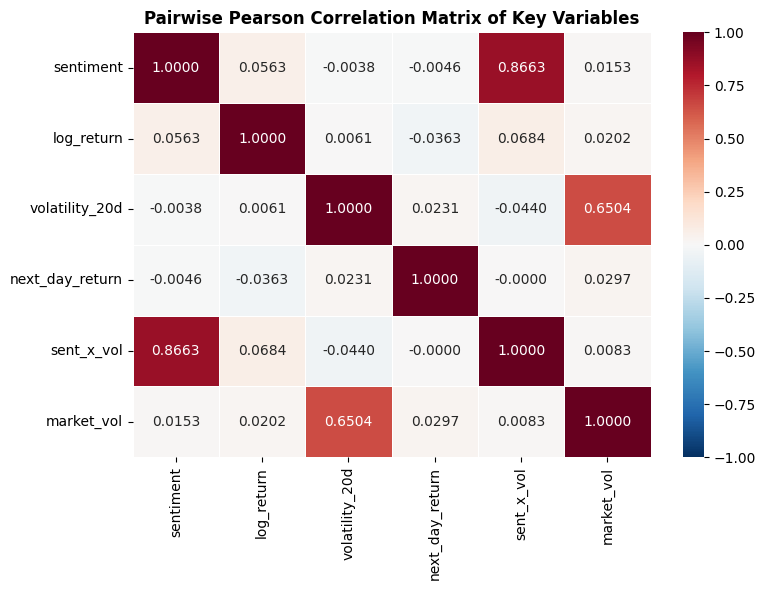

Saved: Fig_Correlation_Matrix.png


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")

corr_vars = ['sentiment', 'log_return', 'volatility_20d', 'next_day_return', 'sent_x_vol', 'market_vol']
corr_matrix = df[corr_vars].corr().round(4)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            xticklabels=corr_vars, yticklabels=corr_vars)
ax.set_title('Pairwise Pearson Correlation Matrix of Key Variables', fontsize=12, fontweight='bold')
plt.tight_layout()

OUTPUT_DIR = r"..\..\Dissertation_Results\EDA"
plt.savefig(os.path.join(OUTPUT_DIR, "Fig_Correlation_Matrix.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig_Correlation_Matrix.png")

In [ ]:
Appendix H — Correlation Matrix